# ANÁLISIS DESCRIPTIVO DE LOS DATOS

## ¿Con qué datos vamos a trabajar?

Los datos con los que trabajamos se trata de secuencias de ARN que transcriben la información de genes no codificantes (su propósito no es construir proteínas sino que tienen otras funciones distintas, pero también relevantes) en el ser humano.
Estas secuencias de ARN son cadenas de nucleótidos. Los nucleótidos son moléculas compuestas por un azúcar, un grupo fosfato y una base nitrogenada. En la cadena de ARN cada nucleótido queda representado por su base nitrogenada, pudiendo ser Adenina (A), Uracilo (U), Citosina (C), o Guanina (G), por lo tanto, cada cadena es en la práctica una sucesión de estas letras.
Concretamente los datos han sido sacados de Ensembl, una base de datos que integra anotación genómica y otros datos biológicos del genoma humano y de otros vertebrados y organismos. Ensembl surge como un proyecto bioinformático gratuito y de código abierto, por el European Bioinformatics Institute (EBI) y el Wellcome Trust Sanger Institute.  
https://ftp.ensembl.org/pub/current_fasta/homo_sapiens/ncrna

Concretamente el formato en el que obtenemos los datos es FASTA. El formato FASTA es un estándar de texto plano utilizado para representar secuencias de nucleótidos. En el archivo, la información correspondiente a cada secuencia consiste en una línea de cabecera que comienza con el símbolo ">" seguido de un identificador único y ciertos metadatos opcionales, y a continuación la sucesión de nucleótidos en líneas subsiguientes, generalmente con un máximo recomendado de 80 caracteres por línea.
En nuestro caso, la cabecera del archivo fasta del que leemos los datos, sigue la siguiente estructura (según su README).


In [1]:
"""La cabecera del archivo .fasta del que leemos los datos sigue la siguiente estructura:
    

>TRANSCRIPT_ID SEQTYPE LOCATION GENE_ID GENE_BIOTYPE TRANSCRIPT_BIOTYPE

Example of an Ensembl ncRNA header:

>ENST00000347977.1 ncrna chromosome:NCBI35:1:217347790:217347874:-1 gene:ENSG00000195671.1 gene_biotype:miRNA transcript_biotype:miRNA
 ^                 ^     ^                                          ^                      ^                  ^ 
 TRANSCRIPT_ID     |     LOCATION                                   GENE_ID                GENE_BIOTYPE       TRANSCRIPT_BIOTYPE
                SEQTYPE

URL del README
https://ftp.ensembl.org/pub/current_fasta/homo_sapiens/ncrna/README

"""
print()

Donde:


-**TRANSCRIPT_ID** -> es el identificador único para cada secuencia de ARN, usado por la base de datos de Ensembl. 
                    Puede ser relevante tenerlo como ID inequívoco de cada secuencia (por si se necesitase en futuras aplicaciones).

-**SEQTYPE** -> Tipo de secuencia. En este caso, son todas de ARN no codificante por lo que no es relevante para el estudio.

-**LOCATION** -> Localización genómica de la secuencia. Permite mapear la secuencia al genoma.

-**GENE_ID** -> Identificador único del gen al que corresponde esa secuencia. El gen se copia en ARN mensajero. 
            Este proceso de copia se lleva a cabo por medio del empalme alternativo, dando lugar a que no todas las secuencias de ARN 
            en las que se transcribe la información del gen sean iguales. 
            Por lo tanto, puedo tener secuencias de ARN que guardan información de un mismo gen, pero ser distintas entre sí.

-**GENE_BIOTYPE**-> Biotipo del gen cuya información se copia en la secuencia de ARN.  Relevante para llevar a cabo la tarea de clasificación.

-**TRANSCRIPT_BIOTYPE** -> Clasificación del transcrito (puede coincidir con el biotipo del gen o diferir). 
                        Un mismo gen puede tener transcritos de distintos tipos funcionales. 
                        Esto quiere decir que un gen, perteneciente a un biotipo en concreto, puede estar transmitiendo 
                        su información por medio de cadenas de ARN distintas, pertenecientes a un biotipo distinto del que pertenece el gen. 
                        Podría ser relevante si preferimos usar este campo en vez del GENE_BIOTYPE para la tarea de clasificación. 


Muestra de una de las secuencias de ARN junto con su cabecera:

In [2]:
"""
>ENST00000837531.1 ncrna chromosome:GRCh38:10:3030045:3035548:-1 gene:ENSG00000287560.2 gene_biotype:lncRNA transcript_biotype:lncRNA description:novel transcript
GCUCUCUUGCCUGCCGCCACAUAAGACAUGACUUUGCUCCUCAUUCAGCUUCCGCCAUGAUUCUGAGGCCUCCCCAGCGA
CGUGAAACUCUUCAAUAAAUAUAGACUGCCGUAUCUCUAUGCAUCAGACAUGUCCAUCCUUUGGUUGAGCGAGACACAGG
GUGAUACGCACUCGCAGGUGCAUACAUGUCCUAUCCUGGUCUGUGAUUUUUCUGUCCAAGAUGGUGGCUGUUGUACCCUU
GAUUUUCUGAAGUCACCAGCACACAGCCUCAGUGCCAGUGGUCAUCAGCCGUGUUAUCAGCUUUCAGAAUUGGAGAGAUG
GGGACCCAGUUUCAUUCUUCCACGUGUUUGCUGUCACUUCUGAUAUGCAUACAGCAAUUUGAAUUGACACUGUACAUUAA
CCAGUAAGAUGAGCUCUGAUUUUGCUCUGACAGCCUGGGGAUGAGGAGCAAGUUGACAAAAUGCUGCAACUUCUGAGGAG
GAAAAAUAAAUCUUACCUAGGAAA
"""

print()

## Exploración de los datos

In [3]:
import math, random, json, pathlib
from typing import List, Tuple
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


def read_fasta(path) -> List[str]:
    """Comenzamos inicializando una lista vacía cur en la que se irán acumulando los tramos de las secuencias (las líneas que no son la cabecera)
        Además inicializamos un diccionario data_dict para poder guardar las secuencias como valores asociados a sus identificadores como claves
        El valor del id y del biotipo de cada secuencia lo inicializamos a None inicialmente."""
    cur = []; localizaciones = dict()
    data_dict = dict()
    id = None
    biotype = None
    with open(path) as f:
        """Abrimos el archivo con los datos e iteramos por todas sus líneas. Debemos tener en cuenta que hay dos tipos de líneas en el archivo.
        Tenemos las cabeceras, que contienen los metadatos de las secuencias y los tramos de secuencias. Una misma secuencia estará dividida en varios tramos.
        La forma que tenemos de distinguir entre los tipos de líneas del dataset es ver si comienzan por el caracter '>' """
        for line in f:
            if line.startswith(">"):   #EL iterador ha llegado a una nueva secuencia.
                """Si la línea actual comienza por el caracter >, significa que estamos ante una cabecera y que comienza una nueva secuencia."""
                """Si la secuencia es la primera del archivo, no entrará en el siguiente if y pasará directamente a extraer el id y biotipo de esa primera secuencia
                quedando así las variables del mismo nombre con valores distintos a None, que es como se inicializan"""
                """Si es una secuencia que no es la primera del archivo, el id y el biotipo tendrán el valor propio de la secuencia anterior que hemos acabado de iterar pero que todavía no hemos guardado
                 además cur guardará todos los tramos de la secuencia anterior que hemos acabado de iterar """
                if id and biotype and cur: 
                    full_sequence = "".join(cur)   #Unimos todos los tramos de una misma secuencia
                    """Si el biotipo no está en el diccionario, lo añadimos y como valor le inicizamos un diccionario vacío en el que se
                       irán acumulando las distintas secuencias de ARN. Las claves serán los IDs de dichas secuencias y los valores las propias secuencias"""
                    if biotype not in data_dict:
                        data_dict[biotype] = {}
                    """Añadimos la secuencia al diccionario propio del biotipo al que pertenece"""
                    data_dict[biotype][id] = full_sequence
                    localizaciones[loc[0]][loc[2]][biotype].append(id)
                    cur = [] # Reiniciar para la nueva secuencia
                """Tanto si es la primera línea del proyecto como si es otra cualquiera, se extrae de la cabecera el id y el biotipo"""
                headers = line.split()
                id = headers[0].strip(">")  
                biotype = headers[4].split(":")[1] 
                """Seleccionamos de la cabecera también la localización genómica de las secuencias para un posterior análisis"""
                loc = headers[2].split(":")
                if not localizaciones.get(loc[0]):
                    localizaciones[loc[0]] = dict()
                if not localizaciones[loc[0]].get(loc[2]):
                    localizaciones[loc[0]][loc[2]] = dict()
                if not localizaciones[loc[0]][loc[2]].get(biotype):
                    localizaciones[loc[0]][loc[2]][biotype] = list()        
            else:  
                """Si la línea actual no comienza por el signo >, significa que estamos ante un trozo de la cadena actual, por lo que añadimos dicho trozo
                a la lista cur para ir acumulando todos los tramos de la secuencia actual"""                             
                cur.append(line.strip())        

        if cur: 
            data_dict[biotype][id] = "".join(cur)
    return data_dict, localizaciones


"""
Con esta función estamos retornando un diccionario como el siguiente:

{Biotipo1 : {ID: seq, ID: seq, ..., ID: seq},
 Biotipo2 : {ID: seq, ID: seq, ..., ID: seq},
 
 ...

 BiotipoN : {ID: seq, ID: seq, ..., ID: seq}}

"""

if __name__ == "__main__":
    fasta = "data/rna_small.fasta" #
    seqs, localizaciones = read_fasta(fasta)
    print('Número de biotipos distintos: ',len(seqs))
    print(len(localizaciones))
    

   

Número de biotipos distintos:  11
2


In [4]:
import numpy as np
from collections import Counter

def all_kmers(k=3):
    vocab = []
    def rec(prefix, k):
        BASES = ["A","C","G","U"]
        if k==0:
            vocab.append(prefix)
            return
        for b in BASES:
            rec(prefix+b, k-1)
    rec("", k)
    return vocab

def cargarDatos(seqs):
    kmers_frequencies = dict()
    longitud_codon = 3
    length_frequencies = dict()
    # length_frequencies = {
    #     'lncRNA': {10: 5, 12: 15, 15: 8, 20: 3},
    #     'snRNA': {8: 10, 10: 20, 11: 15, 13: 5},
    #     # ... (otros biotipos)
    # }
    metadata = [] #Defino metadata como una lista de tuplas. Habrá una tupla por cada biotipo
                #Cada tupla presentará el nombre del biotipo, el número de secuencias que pertenecen a esa clase, el 


    codones = all_kmers()  

    #Hacerlo función
    for biotype, seq_dict in seqs.items():
        print(biotype)
        numero_secuencias = len(seq_dict)
        print("Número de secuencias: ",len(seq_dict))
        print("---"*30)
        """Por cada biotipo inicializo el valor máximo y mínimo de longitud, un Counter para aumular las longitudes de 
        los datos y otro para acumular el conteo de codones"""
        min_len = np.inf; max_len = -np.inf
        lengths_dict = Counter()
        conteo_codones_base = Counter(dict.fromkeys(codones, 0))
        i = 0
        for id, seq in seq_dict.items():

            if i < 5:print(f"{id}: {seq}"); i+= 1
            #Extraigo la longitud de la secuencia, de tal forma que debo incrementar el contador de longitudes
            #También me sirve para poder determinar cual es la longitud máxima y mínima del biotipo en concreto
            longitud_seq = len(seq)
            lengths_dict[longitud_seq] += 1
            if longitud_seq < min_len:
                min_len = longitud_seq
            if longitud_seq > max_len:
                max_len = longitud_seq
            
            """Con tal de poder obtener algo más de información sobre la estructura interna de las secuencias de ARN,
            vamos a llevar un conteo de los codones que componen a cada secuencia. Así podremos sacar la proporción de aparición
            de cada codón en los distintos biotipos teniendo así algo más de información que pudiera ser objeto de interés a posteriri.
            No sacamos el promedio de las proporciones individuales de cada secuencia del biotipo, sino la proporción agregada en todo el biotipo
            (se trata del cociente de la aparición de un codón en toda la muestra del biotipo entre la suma de la aparición de todos los codones del biotipo)"""
            conteo_codones_secuencia = Counter()
            for start in range(0,len(seq),longitud_codon):
                codon = seq[start:start+longitud_codon]
                if len(codon) == longitud_codon and codon in codones:
                    conteo_codones_secuencia[codon] += 1

            conteo_codones_base += conteo_codones_secuencia
        #Guardo el objeto counter con las frecuencias de las longitudes de cada biotipo
        #También guardo el valor de la proporción de las frecuencias de los codones en kmers_frequencies
        #También saco la longitud media de las secuencias de cada biotipo
        kmers_frequencies[biotype] = {codon: total_conteo / sum(conteo_codones_base.values()) for codon, total_conteo in conteo_codones_base.items()}
        length_frequencies[biotype] = lengths_dict
        avg_len = sum(longitud * freq for longitud, freq in lengths_dict.items())/sum(lengths_dict.values())
        metadata.append((biotype, numero_secuencias, max_len, min_len, round(avg_len,2)))

        #Obtenemos la proporción relativa de las frecuencias de aparición de los codones en cada biotipo. Para ello divido el total de veces que ha aparecido
        # un codón en las muestras de ese biotipo, entre la cantidad de codones totales encontrados de todos los tipos para ese biotipo 
                
        print("\n")

    return kmers_frequencies, length_frequencies, metadata

kmers_frequencies, length_frequencies, metadata = cargarDatos(seqs)

lncRNA
Número de secuencias:  34852
------------------------------------------------------------------------------------------
ENST00000837531.1: GCUCUCUUGCCUGCCGCCACAUAAGACAUGACUUUGCUCCUCAUUCAGCUUCCGCCAUGAUUCUGAGGCCUCCCCAGCGACGUGAAACUCUUCAAUAAAUAUAGACUGCCGUAUCUCUAUGCAUCAGACAUGUCCAUCCUUUGGUUGAGCGAGACACAGGGUGAUACGCACUCGCAGGUGCAUACAUGUCCUAUCCUGGUCUGUGAUUUUUCUGUCCAAGAUGGUGGCUGUUGUACCCUUGAUUUUCUGAAGUCACCAGCACACAGCCUCAGUGCCAGUGGUCAUCAGCCGUGUUAUCAGCUUUCAGAAUUGGAGAGAUGGGGACCCAGUUUCAUUCUUCCACGUGUUUGCUGUCACUUCUGAUAUGCAUACAGCAAUUUGAAUUGACACUGUACAUUAACCAGUAAGAUGAGCUCUGAUUUUGCUCUGACAGCCUGGGGAUGAGGAGCAAGUUGACAAAAUGCUGCAACUUCUGAGGAGGAAAAAUAAAUCUUACCUAGGAAA
ENST00000784990.1: GUAUUAUCUACAGGCACUAAGAUCCUGAAAAUGUCUUUUCCUCUUCACAUUACACACAAGGAAACCAGACUGUGAACAUAACAAUGAGUUACUUGAAAAUUAAAGGACCCUGAUCCAUCAAUAUGACUACACAUUUGAUUGGACAAAGUUAAAGCAGAAAGCAGCACAGCAGGCAGCCUCUUCUAGUGGGAGGGGCAGCAGGCCCAAACCCCAACAGGGUAUUUAGAGAAAUUCAAUCAGAGACGAUGGAACUAAAGCUGGCCCUUCUGUGCAUACCUGUUUCCUAAAGAAAUGUUUACUCCUGGAUUGGGUCAGCCCCUCUGCAUUUAC

PROPORCIONES AGREGADAS DE LOS CODONES EN CADA BIOTIPO

In [5]:
import pandas as pd

pd.DataFrame(kmers_frequencies).fillna(0)

,lncRNA,snRNA,snoRNA,misc_RNA,miRNA,rRNA,ribozyme,scaRNA,Mt_tRNA,vault_RNA,sRNA
AAA,0.031465,0.040515,0.023874,0.020424,0.017532,0.008517,0.0128,0.021808,0.052411,0.007519,0.000000
AAG,0.023477,0.020072,0.017049,0.014882,0.016918,0.022711,0.0224,0.021015,0.014675,0.007519,0.000000
AAU,0.018399,0.016610,0.016178,0.012732,0.013192,0.026260,0.0080,0.009516,0.020964,0.015038,0.000000
ACA,0.018688,0.029031,0.018425,0.014542,0.014949,0.015614,0.0080,0.019429,0.020964,0.000000,0.078947
ACC,0.013970,0.007057,0.010954,0.015677,0.012408,0.034067,0.0064,0.011499,0.014675,0.037594,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
CGA,0.004294,0.003833,0.002556,0.003058,0.003790,0.005678,0.0016,0.003172,0.008386,0.022556,0.000000
AAC,0.014699,0.008409,0.014409,0.013253,0.009613,0.012065,0.0128,0.011895,0.020964,0.022556,0.000000
CGC,0.005849,0.003536,0.002584,0.004734,0.006903,0.004968,0.0048,0.005551,0.002096,0.037594,0.006579
CGG,0.006836,0.002035,0.002696,0.004280,0.008660,0.014194,0.0048,0.006741,0.004193,0.037594,0.000000


El propósito de este proyecto es entrenar un modelo BERT-like basado en arquitectura Transformer mediante preentrenamiento enmascarado (masked language modeling), con el objetivo de que aprenda las relaciones internas entre nucleótidos en secuencias de ARN. Así, el modelo intentará capturar relaciones internas biológicamente relevantes que posteriormente podrán explotarse en tareas concretas.
Como tarea a posteriori proponemos la clasificación de secuencias según el biotipo del gen (campo gene_biotype)
Para ello conviene analizar las clases de este conjunto de datos con el que trabajaremos.


DESCRIPCIÓN BÁSICA LONGITUDES DE LAS SECUENCIAS DE ARN

In [6]:
import pandas as pd

pd.DataFrame(metadata, columns=["Biotipo", "Nº Secuencias", "max_length", "min_length", "avg_len"])



,Biotipo,Nº Secuencias,max_length,min_length,avg_len
0,lncRNA,34852,512,60,407.74
1,snRNA,1851,328,60,110.38
2,snoRNA,924,330,60,116.57
3,misc_RNA,2175,464,61,207.54
4,miRNA,1714,180,60,83.63
5,rRNA,35,153,84,122.11
6,ribozyme,8,333,78,235.00
7,scaRNA,48,420,83,158.77
8,Mt_tRNA,21,75,65,69.00
9,vault_RNA,4,128,89,101.25


La muestra con la que trabajamos está compuesta por un total de 41.635 secuencias, de entre 60 y 512 nucleótidos. Concretamente repartidas en 11 clases o biotipos distintos. Se puede ver como hay un enorme desbalanceo entre las clases, perteneciendo 34.852 de ellas al biotipo lncRNA (long non-coding RNA), que es el más poblado, frente a tan solo 3 secuencias que se identifican con el biotipo sRNA.


Visualizamos las frecuencias del tamaño de las secuencias por cada biotipo.

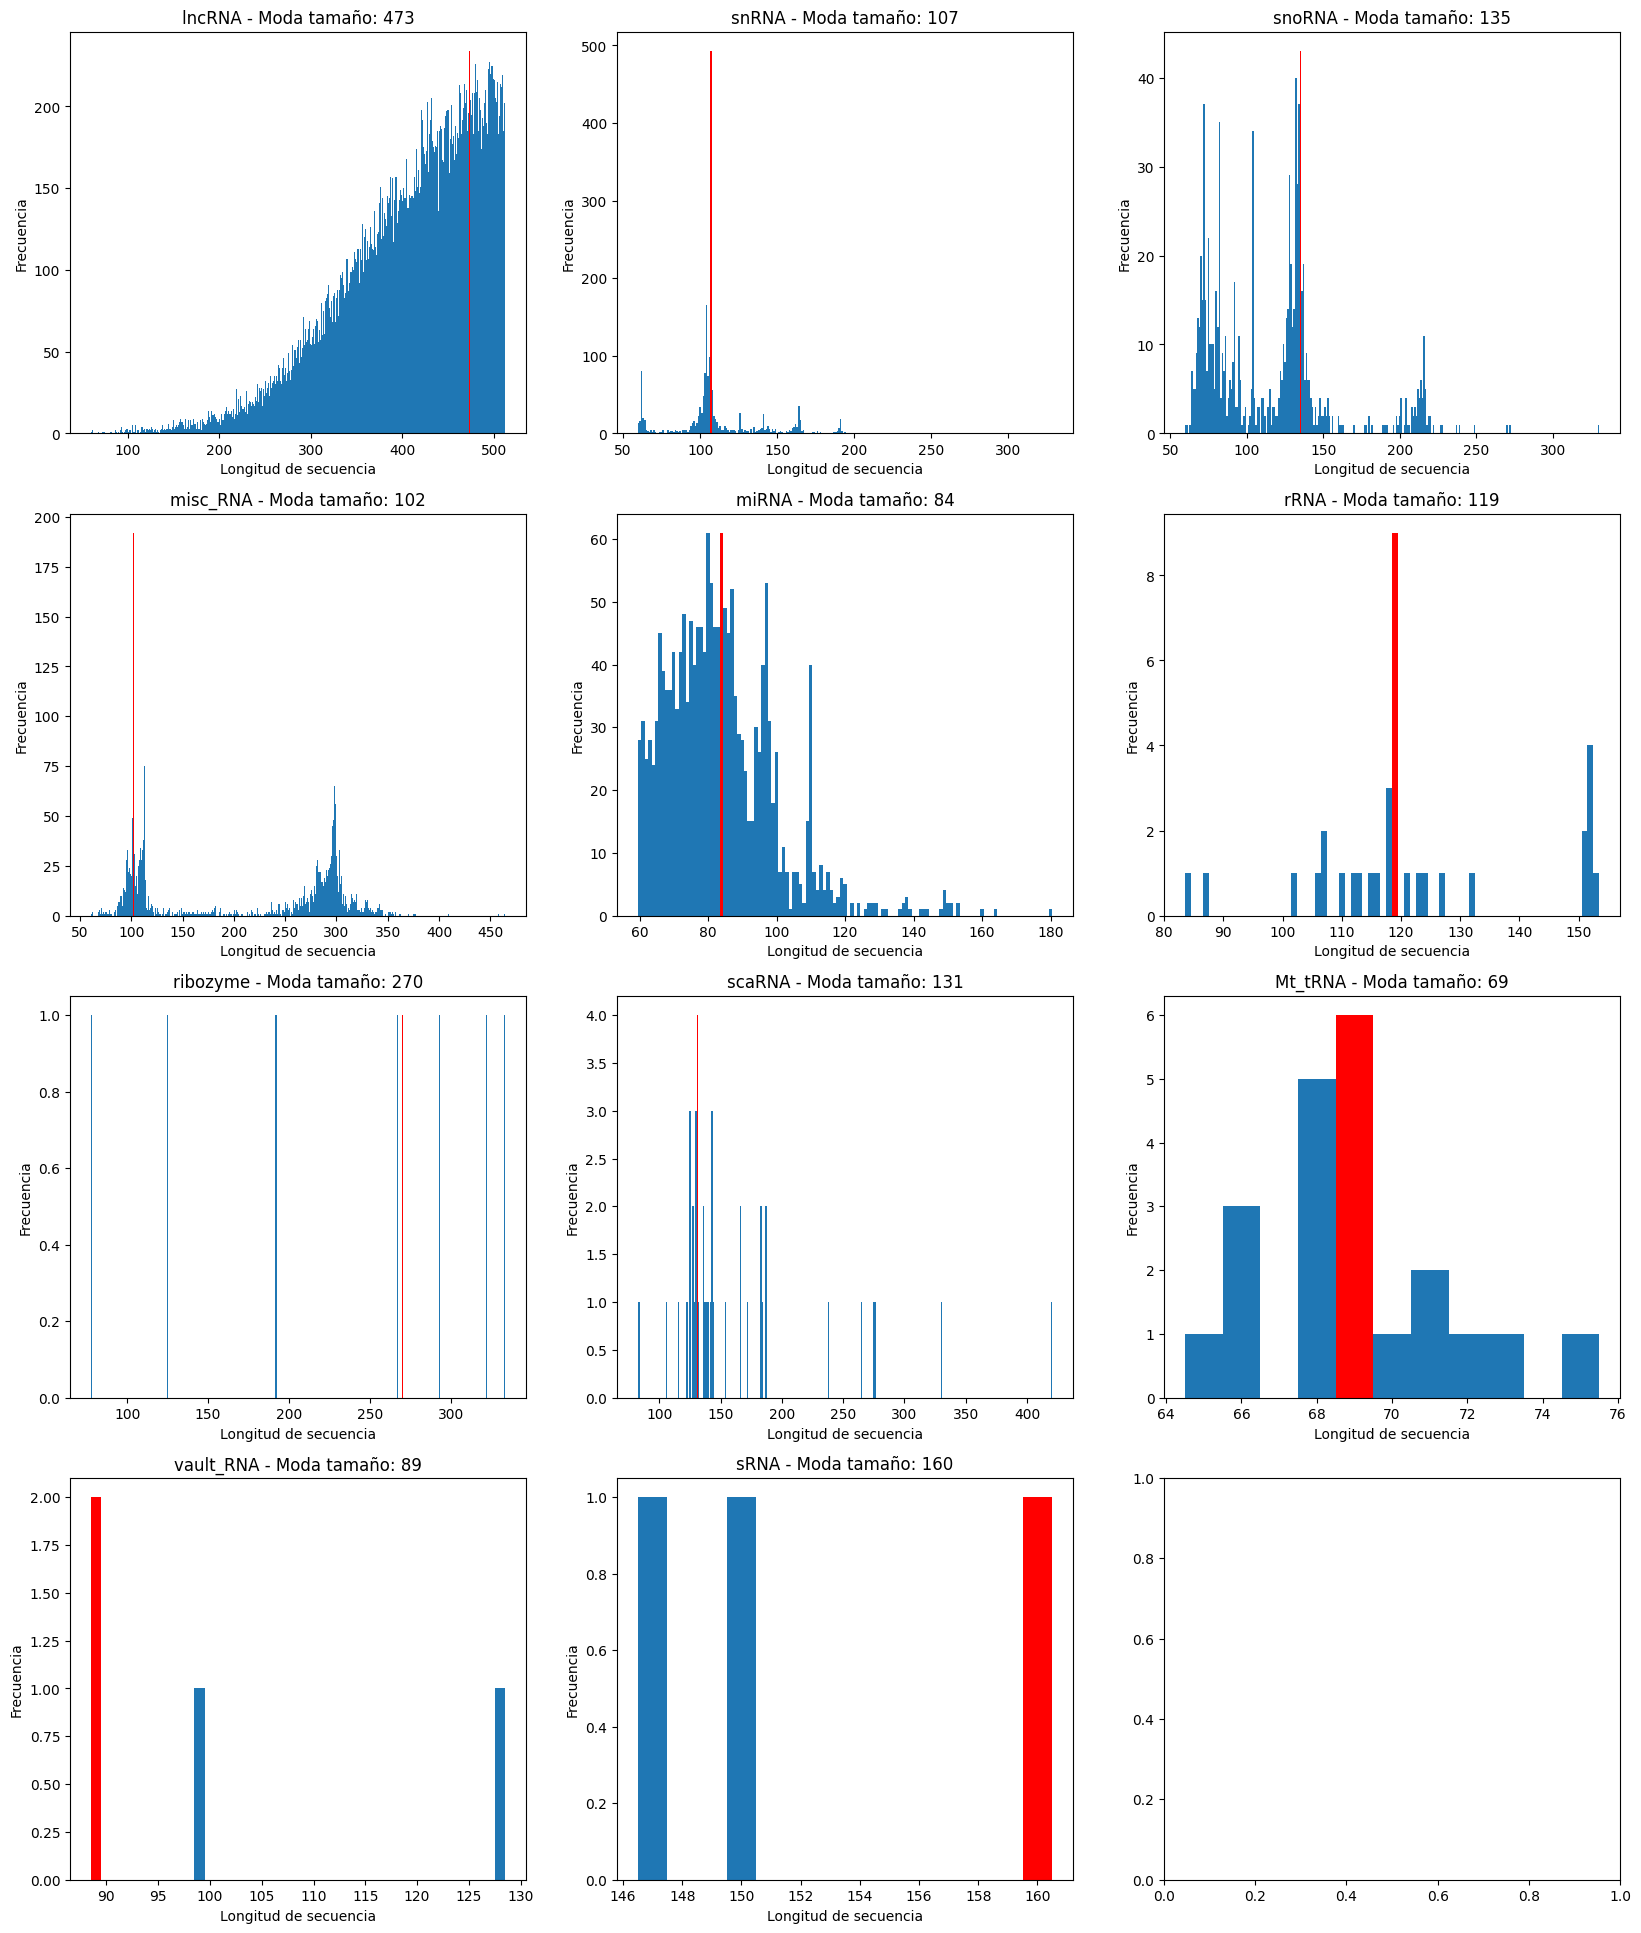

In [7]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(4, 3, figsize=(4 * 5, 4 * 6))
axes_flatten = axes.flatten()
for i,(biotype, counter) in enumerate(length_frequencies.items()):
    x = sorted(counter.keys())
    y = [counter[k] for k in x]
    moda = max(counter, key=counter.get)
    colors = ['red' if k == moda else '#1f77b4' for k in x]
    ax = axes_flatten[i]
    ax.bar(x, y, width=1, color = colors)
    ax.set_title(f"{biotype} - Moda tamaño: {moda}")
    ax.set_xlabel("Longitud de secuencia")
    ax.set_ylabel("Frecuencia")
plt.show()
fig.tight_layout()

La visualización de estos gráficos de barras evidencia como hay clases muy poco pobladas, es decir, clases que son poco comunes, cuyas secuencias tienen longitudes muy dispares, dando lugar incluso a frecuencias de longitud de una sola instancia (es decir solo una secuencia en esa clase tiene ese tamaño) por lo que convendría agrupar todas esas clases en una sola llamada 'otros', y centrarnos más en las clases que presentan mayor variabilidad.

Los gráficos muestran dos características principales: primero, que la mayoría de las secuencias de la muestra se concentran en pocos biotipos. Segundo, que las clases más pobladas (como lncRNA, snRNA, y miRNA) presentan masas de frecuencias muy concentradas en rangos de longitudes concretas. 


Para continuar estudiando las distribuciones de longitud de las secuencias, descartamos aquellas clases con muy pocos ejemplos, quedándonos solo con lncRNA, snRNA, miRNA, misc_RNA y snoRNA, agrupando las demás clases en ‘otros’.


1.Acumulamos todas las clases poco pobladas en una única llamada otros.

In [8]:
otros = Counter()
for biotype, counter in length_frequencies.items():
    if biotype not in ['lncRNA', 'snRNA', 'miRNA', 'misc_RNA', 'snoRNA']:
        otros += counter
length_frequencies['otros'] = otros

2.1 Aplicando un histograma con bins de tamaño 25. De forma que se agrupen las longitudes dando lugar a una visualización mucho más descriptiva, al reducirse el ruido y hacerse más visible la tendencia.

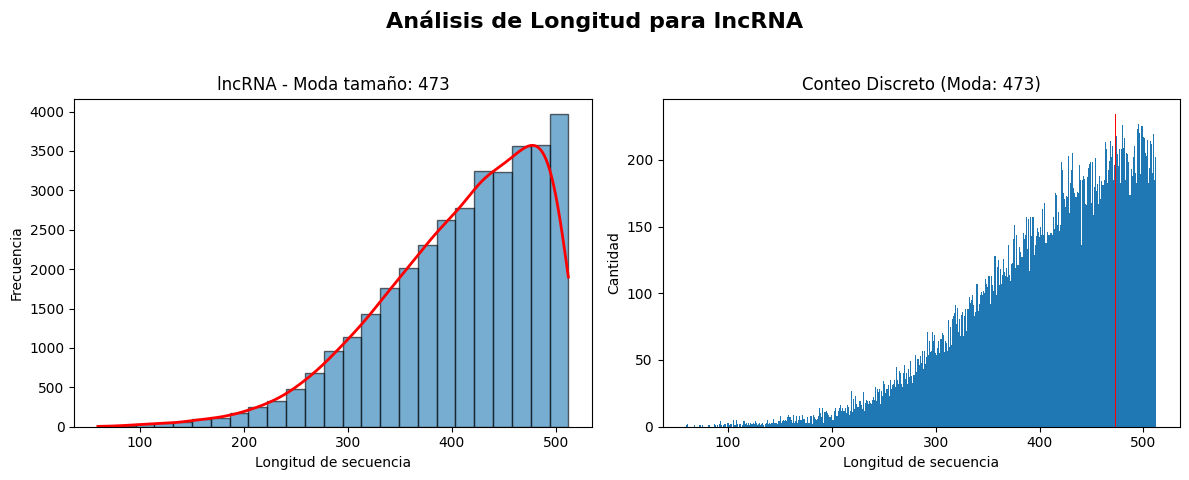

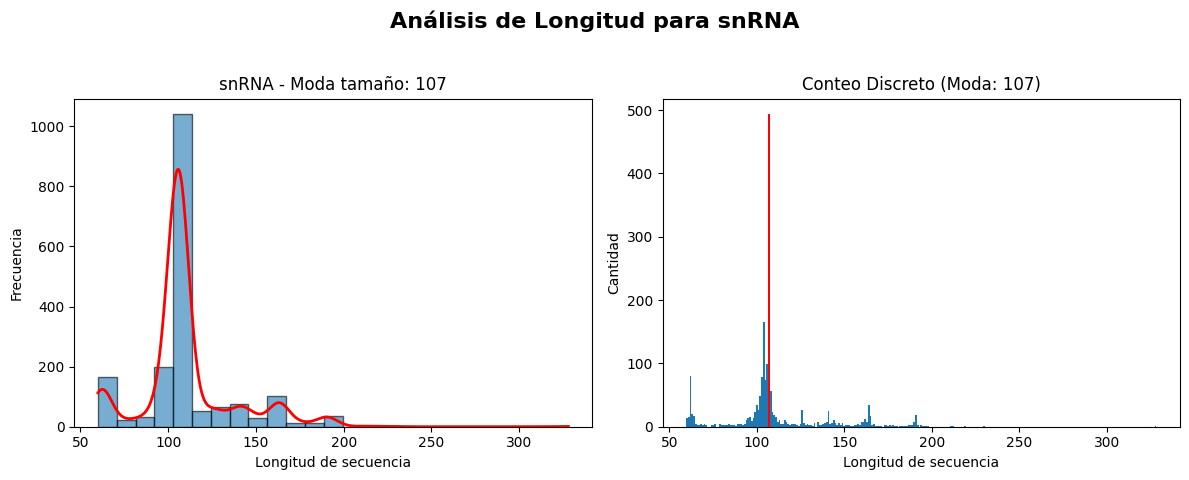

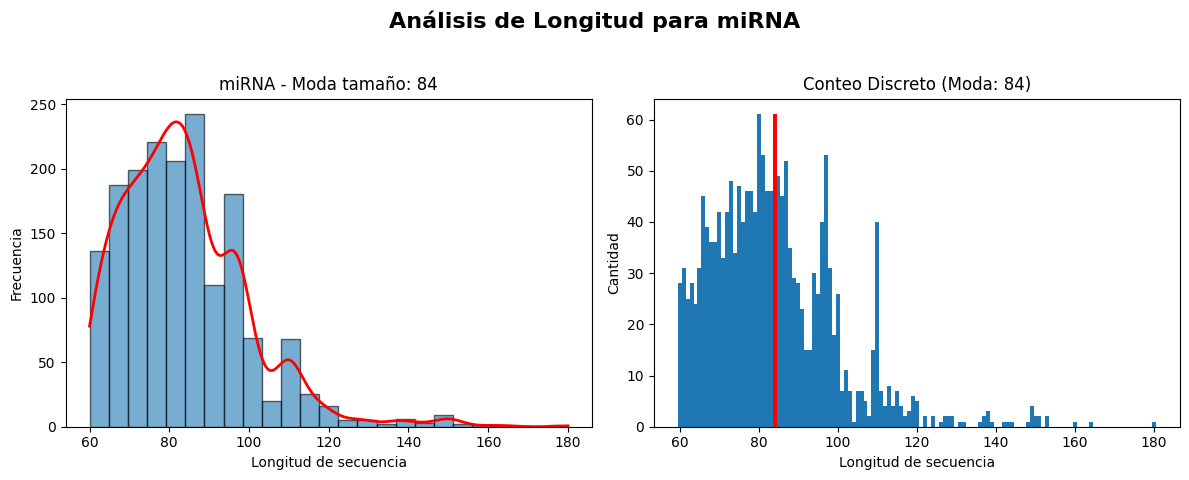

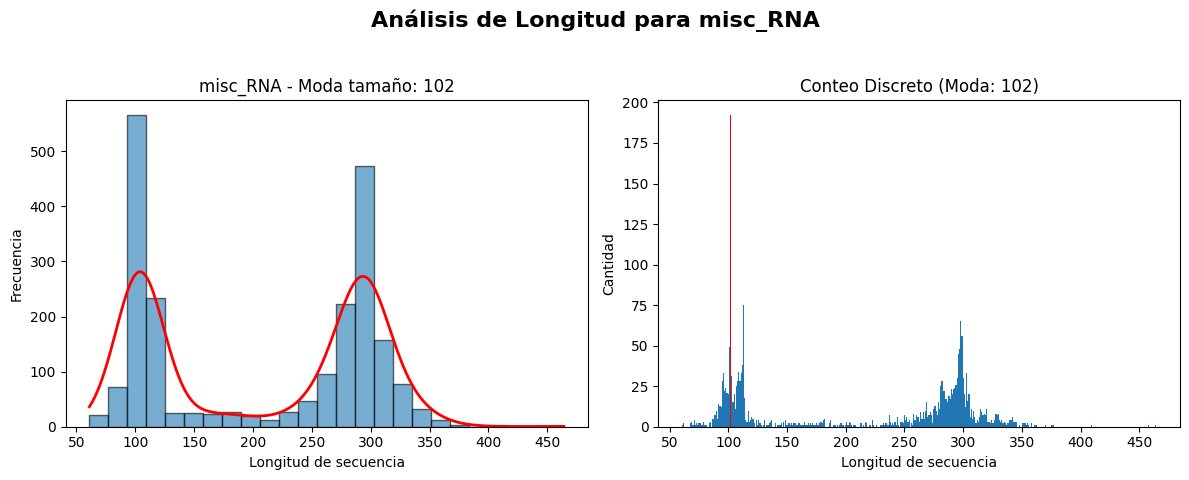

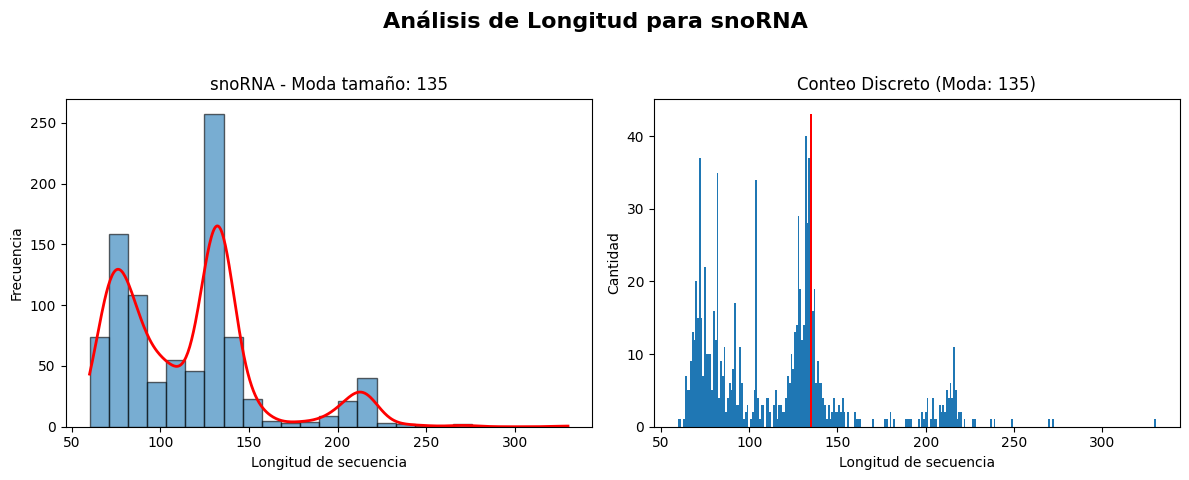

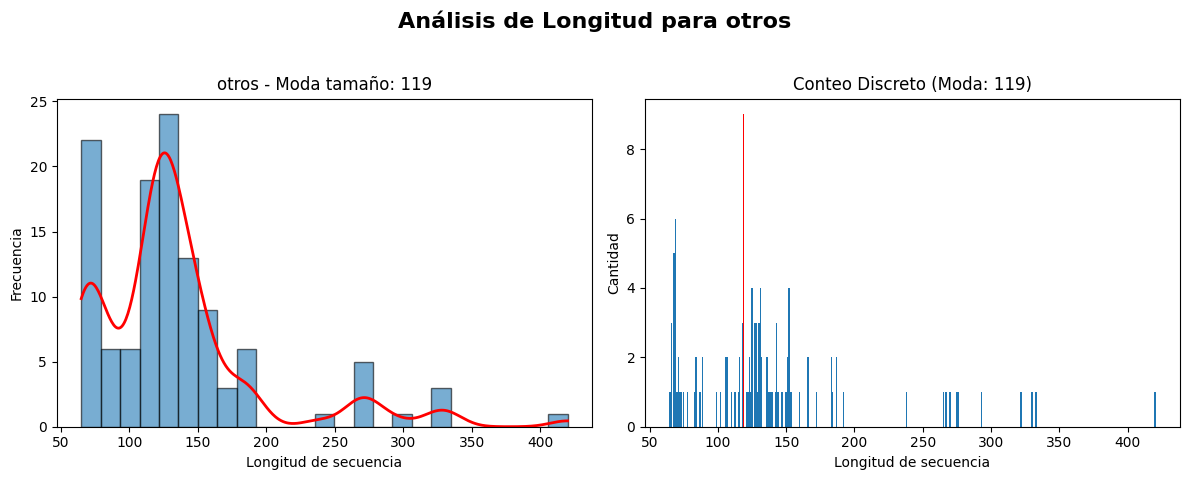

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import chain, repeat
from scipy.stats import gaussian_kde

# Establecer el tamaño de la figura (opcional, pero mejora la visibilidad lado a lado)
FIGSIZE = (12, 5) 

for biotype in ['lncRNA', 'snRNA', 'miRNA', 'misc_RNA', 'snoRNA','otros']:
    
    counter = length_frequencies[biotype]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE)
    fig.suptitle(f'Análisis de Longitud para {biotype}', fontsize=16, fontweight='bold')
    
    # Expandimos las longitudes según su frecuencia
    longitudes = list(chain.from_iterable(repeat(k, v) for k, v in counter.items()))
    
    moda = max(counter, key=counter.get)
    
    num_bins = 25
    bin_width = (max(longitudes) - min(longitudes)) / num_bins

    # Curva KDE
    kde = gaussian_kde(longitudes, bw_method=0.2)
    x_range = np.linspace(min(longitudes), max(longitudes), 512)

    ax1.hist(longitudes, bins=num_bins, edgecolor='black', alpha=0.6)
    ax1.plot(x_range, kde(x_range) * len(longitudes) * bin_width, color='red', lw=2) # Escalamos la KDE al histograma: multiplicar por total de datos * ancho de bin
    ax1.set_title(f"{biotype} - Moda tamaño: {moda}")
    ax1.set_xlabel("Longitud de secuencia")
    ax1.set_ylabel("Frecuencia")
        
    x = sorted(counter.keys())
    y = [counter[k] for k in x]
    colors = ['red' if k == moda else '#1f77b4' for k in x]
    
    ax2.bar(x, y, width=1, color=colors)
    ax2.set_title(f"Conteo Discreto (Moda: {moda})")
    ax2.set_xlabel("Longitud de secuencia")
    ax2.set_ylabel("Cantidad")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()


2.3 Comparación entre biotipos

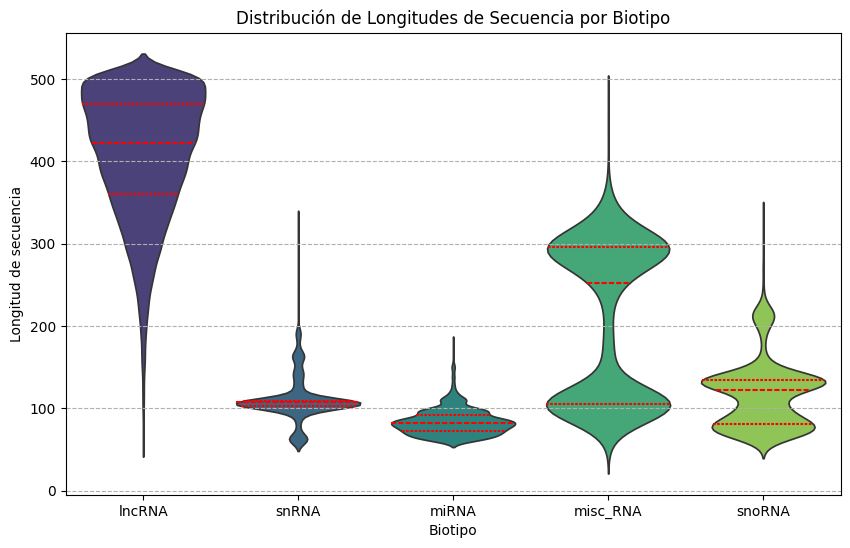

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import chain, repeat
datos_violin = []

selected_biotypes = [ 'lncRNA','snRNA', 'miRNA', 'misc_RNA', 'snoRNA']

for biotipo in selected_biotypes:
    
    counter = length_frequencies[biotipo]
    longitudes = list(chain.from_iterable(repeat(k, v) for k, v in counter.items()))

    for longitud in longitudes:
        datos_violin.append({
            'Longitud': longitud, 
            'Biotipo': biotipo
        })

df = pd.DataFrame(datos_violin)

plt.figure(figsize=(10, 6))


sns.violinplot(
    x='Biotipo', 
    y='Longitud', 
    data=df, 
    hue = 'Biotipo',
    palette='viridis', 
    inner='quartile',   #
    inner_kws={'color': 'red', 'linewidth': 1.5, 'markeredgecolor': 'white'},
    legend = False,
    density_norm='count' #Dado que los datos no están balanceados, me interesa poder representar la anchura de los violines
)                        #conforme al tamaño de la clase a la que pertenecen

plt.title("Distribución de Longitudes de Secuencia por Biotipo")
plt.xlabel("Biotipo")
plt.ylabel("Longitud de secuencia")

plt.grid(axis='y', linestyle='--')
plt.show()

## ¿QUÉ LECTURA PODEMOS EXTRAER DE LOS BIOTIPOS Y SUS LONGITUDES?


Atendiendo a las gráficas, tanto a los histogramas como a los violines, podemos sacar las siguientes conclusiones sobre los biotipos y sus distribuciones de las longitudes.

-**lncRNA (Long Non-Coding RNA)**: Se trata de aquellas secuencias de cadena más larga, así lo indica la distribución de las longitudes de sus secuencias, teniendo la longitud mediana por encima de los 400 nucleótidos, además tienen un rango de longitudes muy amplio. Las secuencias pertenecientes a este biotipo no son solamente las de mayor longitud, sino también las más numerosas, siendo más del 83% de la muestra (34852 de 41635). Gracias a su longitud, cumplen funciones biológicas regulatorias muy diversas en la célula, como adoptar estructuras secundarias y terciarias complejas que permiten interactuar simultáneamente con varias proteínas.

-**snRNA (Small Nuclear RNA)**: El biotipo snRNA presenta una distribución centrada en longitudes entre los 100 y 125 nucléotidos, siendo la moda 107 nucleótidos por cadena, aunque pueden presentar algun ejemplo de longitud algo superior, e incluso outliers cercanos a los 300 nucleótidos. La corta longitud de las secuencias de snRNA es lo que les da la estructura, la agilidad de hibridación, y la flexibilidad necesarias para llevar a cabo sus funciones biológicas en el espliceosoma.

-**miRNA (Micro RNA)**: Tiene la distribución de longitudes más corta y concentrada, con una moda en los 84 nucleótidos y escasa variabilidad (son las secuencias de menor longitud promedio de toda la comparación). Esta distribución compacta y de corta longitud tiene explicación biológica, ya que los miRNAs no funcionan como largas estructuras de andamiaje, sino que se procesan a una longitud madura mucho más corta para integrarse en el complejo RISC. 


-**misc_RNA (Miscellaneous RNA)**: En este biotipo la distribución de las longitudes sigue un patrón claramente bimodal. Presenta un pico inferior centrado en los 100 nucleótidos, y otro pico superior centrado alrededor de los 300 nucleótidos. La mediana queda en torno a una longitud de 250 nucleótidos, lo que indica que hay más ejemplos cercanos al pico superior que al inferior. Entre ambos picos de la distribución hay un valle poco poblado, en el que se enmarcan las secuencias de longitudes entre 180 y 250, lo que refleja escasez de ejemplos con esas longitudes.
Esta naturaleza bimodal de la distribución se asocia directamente a que en esta categoría, miscellaneous RNA, se agrupan aquellas moléculas que no encajan en los demás biotipos, pero sí tienen funciones conocidas. Se agrupan secuencias con funciones dispares bajo un mismo nombre. Por lo tando podemos estimar, que a pesar de ser secuencias agrupadas en las misma clase, muy probablemente las de cadenas más cortas tengan funciones biológicas muy distintas a aquellas con longitudes más largas.

-**snoRNA (Small Nucleolar RNA)**: La distribución de las longitudes en este biotipo refleja que está formado por secuencias de cadena corta, estando la mediana en torno a 120 nucleótidos y la gran mayoría por debajo de los 150.  Hay una cierta disminución del numéro de muestras entre los 90 y 110 nucleótidos, lo que acentúa dos picos de acumulaciones tanto por encima como por debajo de ese rango. Esto nos sugiere la posible existencia de dos o más subtipos, que desempeñen funciones algo distintas dependiendo de sus longitudes. La distribución presenta también una pequeña acumulación de secuencias en torno a las 220 nucleótidos.

## ¿Podemos ver algun patrón intrínseco en la estructura de las secuencias?



El siguiente dataset recoge las proporciones agregadas de cada codón dentro del conjunto de muestras de cada biotipo. Cada valor se ha calculado como el número total de apariciones de un codón en todas las secuencias pertenecientes a un mismo biotipo, dividido entre la suma de las apariciones de todos los codones observados en ese biotipo.

Este enfoque tiene como objetivo analizar si la composición global de los codones presenta características o indicios que sugieran que un modelo de aprendizaje profundo podría identificar patrones significativos no evidentes a simple vista. Sin embargo, dado que este análisis no considera el orden de los codones dentro de las secuencias y los trata de manera independiente, se pierde información estructural sobre las cadenas. Por tanto, no puede garantizarse que un modelo sea capaz de capturar patrones o relaciones posicionales relevantes que permitan discriminar de forma efectiva entre biotipos.

In [11]:
df = pd.DataFrame(kmers_frequencies)

df[selected_biotypes]


,lncRNA,snRNA,miRNA,misc_RNA,snoRNA
AAA,0.031465,0.040515,0.017532,0.020424,0.023874
AAG,0.023477,0.020072,0.016918,0.014882,0.017049
AAU,0.018399,0.016610,0.013192,0.012732,0.016178
ACA,0.018688,0.029031,0.014949,0.014542,0.018425
ACC,0.013970,0.007057,0.012408,0.015677,0.010954
...,...,...,...,...,...
CGA,0.004294,0.003833,0.003790,0.003058,0.002556
AAC,0.014699,0.008409,0.009613,0.013253,0.014409
CGC,0.005849,0.003536,0.006903,0.004734,0.002584
CGG,0.006836,0.002035,0.008660,0.004280,0.002696


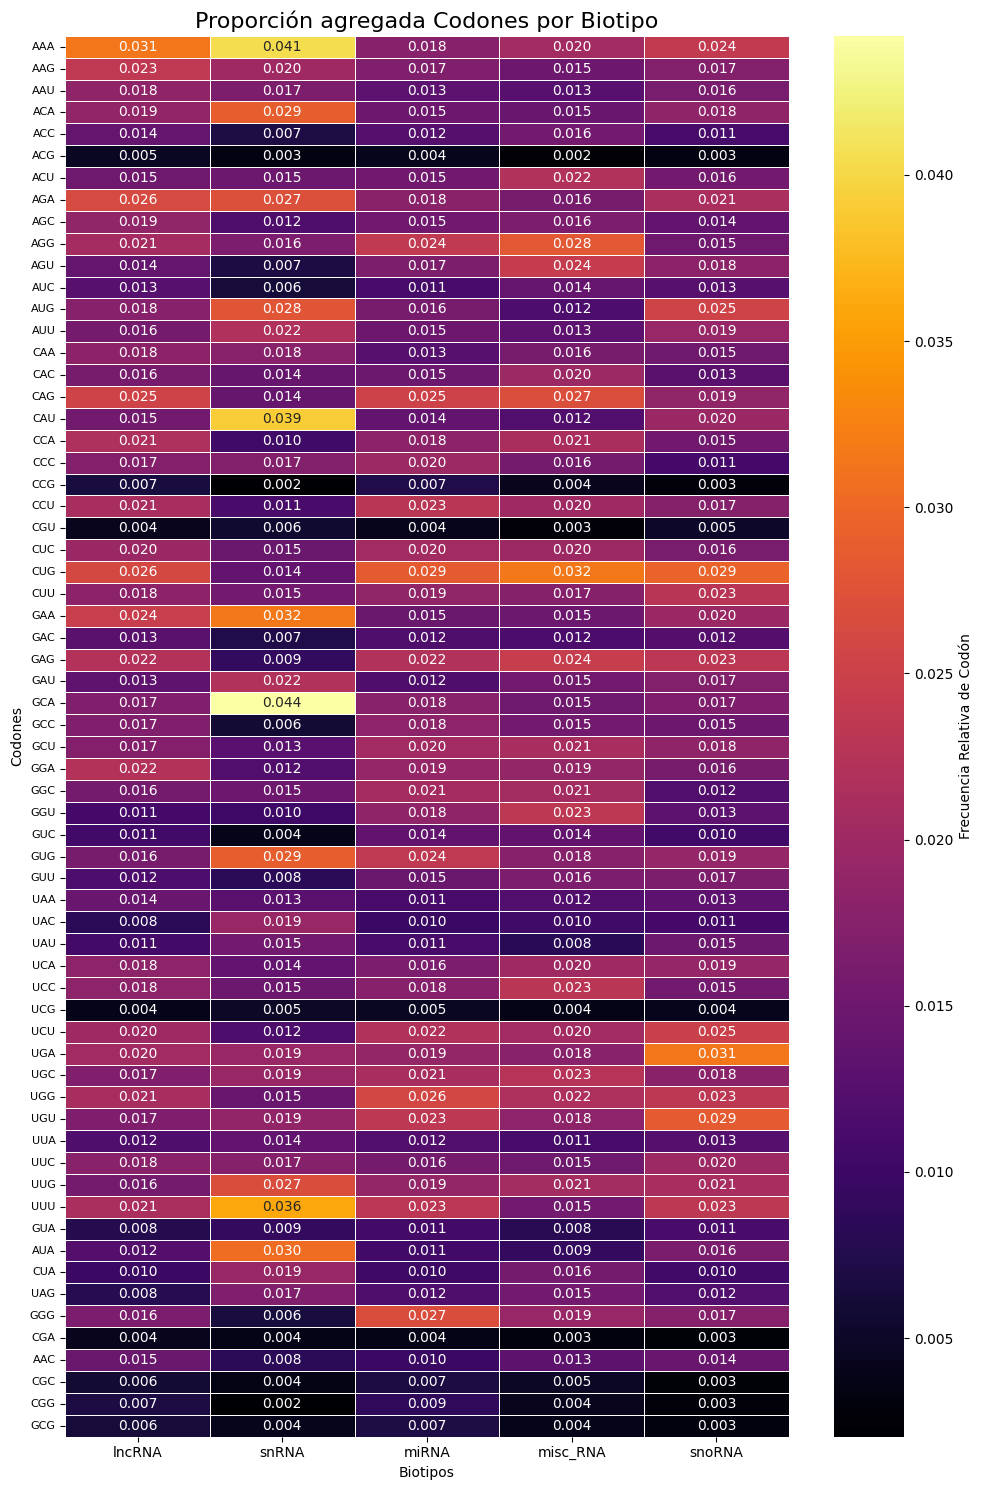

In [12]:
fig, ax = plt.subplots(figsize=(10, 15)) 

codon_labels = df.index.tolist()

df_heatmap = df[selected_biotypes]

sns.heatmap(
    df_heatmap, 
    cmap='inferno', 
    annot=True, 
    fmt=".3f",
    linewidths=0.5, 
    linecolor='white',
    cbar_kws={'label': 'Frecuencia Relativa de Codón'},
    ax=ax 
)


ax.set_yticks(np.arange(len(codon_labels)) + 0.5, minor=False)
ax.set_yticklabels(codon_labels, rotation=0, fontsize=8) 

ax.set_title('Proporción agregada Codones por Biotipo', fontsize=16)
ax.set_xlabel('Biotipos') 
ax.set_ylabel('Codones') 
plt.tight_layout()
plt.show()

En este mapa de calor, los valores representan la proporción agregada de cada uno de los 64 codones posibles en los distintos biotipos.

Se observa claramente que el biotipo snRNA destaca entre los cinco comparados, debido a una mayor presencia de determinados codones (como AAA, AGA, GCA y GUA), así como a una menor frecuencia de otros que sí son más comunes en los demás biotipos. Este patrón sugiere que dichas diferencias podrían constituir una característica distintiva de las secuencias pertenecientes a este biotipo.

Por el contrario, los demás biotipos presentan una distribución de codones más uniforme, lo que dificulta identificar una prevalencia marcada de algunos codones específicos.

En conjunto, estas diferencias composicionales observadas en el biotipo snRNA podrían representar una señal informativa útil para distinguirlo de los demás.

A continuación, se proyectan los biotipos en un plano considerando únicamente las frecuencias de aparición de los codones, con el objetivo de evaluar si son separables entre sí. Este análisis permite valorar la viabilidad de que un modelo de aprendizaje automático pueda utilizar dichas frecuencias como variables predictoras para clasificar las secuencias según su biotipo

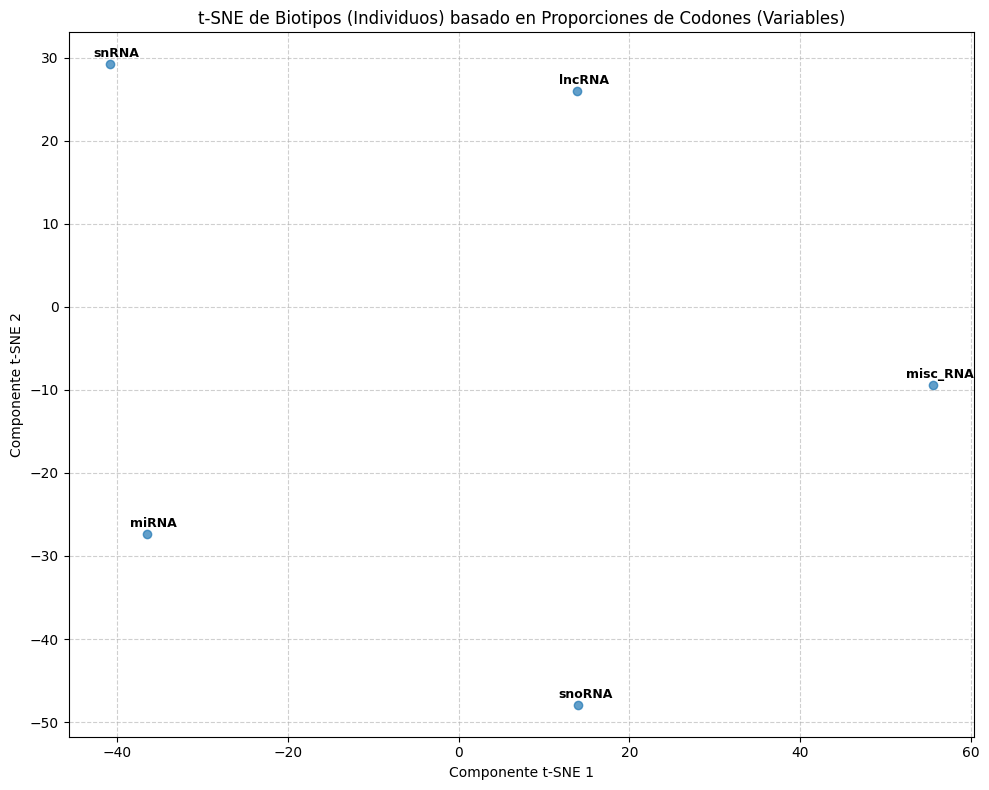

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


X = df[selected_biotypes].T
biotipos = df[selected_biotypes].T.index.tolist()


perplexity_value = min(50, len(biotipos) - 1)

# Se ejecuta la proyección de 64D a 2D
tsne = TSNE(
    n_components=2,           
    random_state=42,          
    perplexity=perplexity_value,
    n_iter=1000               
)
X_tsne = tsne.fit_transform(X)


plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7)


for i, biotipo in enumerate(biotipos):
    plt.annotate(
        biotipo, 
        (X_tsne[i, 0], X_tsne[i, 1]), 
        textcoords="offset points", 
        xytext=(5, 5), 
        ha='center', 
        fontsize=9,
        fontweight='bold'
    )

plt.title('t-SNE de Biotipos (Individuos) basado en Proporciones de Codones (Variables)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

La proyección t-SNE de los cinco biotipos, basada en las proporciones agregadas de codones, revela una separabilidad evidente entre ellos en un espacio bidimensional. Cada biotipo ocupa una región diferenciada del plano, lo que sugiere que las frecuencias relativas de los codones contienen información suficiente para distinguirlos entre sí.

Además, el biotipo snRNA aparece algo más alejado de los demás, coherente con las diferencias composicionales observadas previamente en el mapa de calor.

Estos resultados sugieren que un modelo de aprendizaje automático podría potencialmente aprovechar las frecuencias de codones como variables discriminativas, incluso sin considerar la información secuencial, para clasificar las secuencias por biotipo.

## ¿QUÉ PODEMOS DECIR DE LA DISTRIBUCIÓN DE LOS BIOTIPOS EN LOS CROMOSOMAS?

La siguiente tabla muestra la proporción de biotipos en cada cromosoma, conforme a los datos de localización de las cabeceras de las secuencias.

In [14]:
import pandas as pd
records = []
for chr, chr_dict in localizaciones['chromosome'].items():
    for biotipo, list_ids in chr_dict.items():
        records.append({
                    'Cromosoma': chr,
                    'Biotipo': biotipo,
                    'Conteo': len(list_ids)
                })

df_conteo = pd.DataFrame(records)
df_distribucion_absoluta = df_conteo.pivot_table(
        index='Cromosoma',
        columns='Biotipo',
        values='Conteo'
    ).fillna(0) 
        
df_proporcion = df_distribucion_absoluta.div(df_distribucion_absoluta.sum(axis=1), axis=0) * 100

df_proporcion[selected_biotypes]

Biotipo,lncRNA,snRNA,miRNA,misc_RNA,snoRNA
Cromosoma,,,,,
1,83.122718,5.447908,4.015726,5.054760,1.853412
10,85.930736,4.274892,3.571429,4.653680,1.461039
11,82.049763,3.909953,5.450237,5.272512,2.962085
12,84.344423,4.598826,3.571429,5.577299,1.810176
13,84.977778,3.644444,3.288889,6.577778,1.511111
14,78.792236,3.953990,6.542056,5.463695,4.960460
15,81.969395,3.326680,3.592814,4.457751,6.453759
16,86.893555,3.403331,4.344678,3.113686,2.172339
17,82.064897,4.247788,5.604720,4.955752,2.713864


<Figure size 1800x800 with 0 Axes>

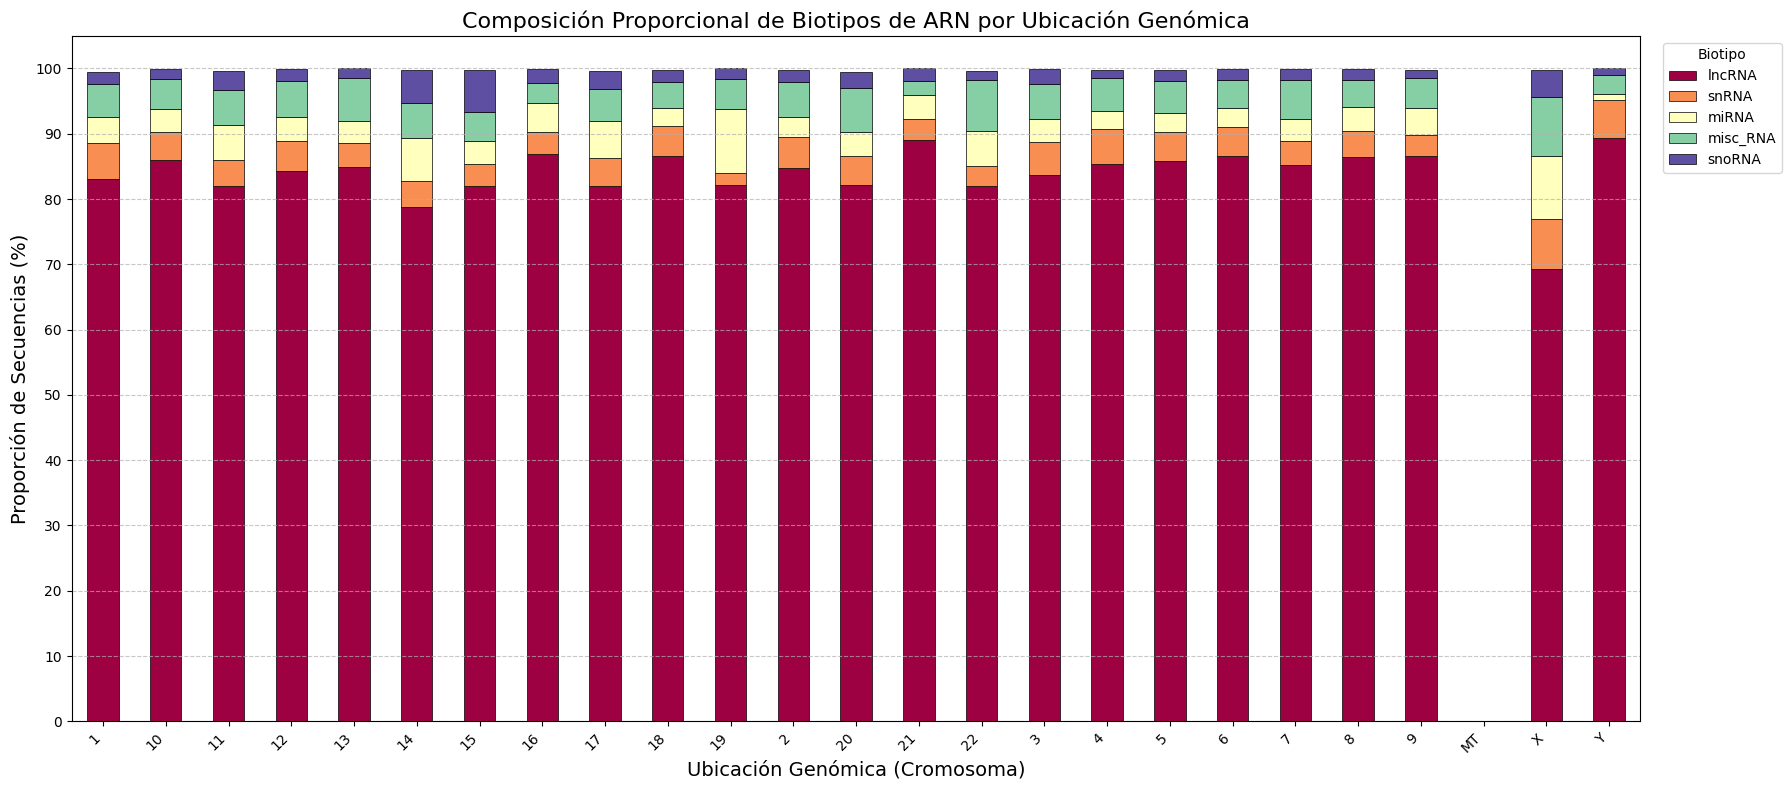

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(18, 8))

ax = df_proporcion[selected_biotypes].plot(kind='bar', stacked=True, figsize=(18, 8), colormap='Spectral', edgecolor='black', linewidth=0.5)

plt.title('Composición Proporcional de Biotipos de ARN por Ubicación Genómica', fontsize=16)
plt.xlabel('Ubicación Genómica (Cromosoma)', fontsize=14)
plt.ylabel('Proporción de Secuencias (%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(np.arange(0, 101, 10))

# Colocar la leyenda fuera del gráfico
plt.legend(title='Biotipo', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Este gráfico de barras apiladas muestra la composición interna de cada ubicación genómica, en términos d elos 5 biotipos que estamos analizando.

Podemos apreciar como las proporciones de los biotipos en los cromosomas se mantienen notablemente estables, presntando más o menos todos la misma proporción de biotipos.
Se da claramente un dominio del biotipo lncRNA, en prácticamente todos los cromosomas, representa consistentemente más del 80% de las secuencias en cada uno de ellos. 
Podemos destacar también como el único cromosoma con menor densidad relativa de lncRNA es el X, cayendo por debajo del 70%. También en dicho cromosoma se da un aumento significativo del biotipo misc_RNA y miRNA.

Si bien la frecuencia de aparición de codones puede ser diferente entre biotipos (como se vio en el heatmap),la distribución de los biotipos en el genoma es en gran medida independiente de la ubicación exacta de cada secuencia.
Este indica que la funcionalidad del ARN es una característica conservada independientemente de si el gen se encuentra en unn cromosoma u otro. 
